# SleepSense — Model Training & Evaluation (LOUO-CV)

This notebook trains and evaluates the baseline, Random Forest, and XGBoost regressor models using Leave-One-User-Out (LOUO) cross-validation. It generates a model comparison table and plots performance metrics, confusion matrices, and prediction trends.

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from src.models.trainer import load_data, run_louo_cv

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Run Leave-One-User-Out Cross-Validation

We will evaluate all three models using LOUO-CV to ensure they generalize to completely unseen users.

In [2]:
df, X, y, user_ids = load_data()

print("Evaluating Baseline Heuristic (User Mean)... ")
y_pred_base, base_metrics = run_louo_cv('baseline', X, y, user_ids)

print("Evaluating Random Forest Regressor... ")
y_pred_rf, rf_metrics = run_louo_cv('rf', X, y, user_ids)

print("Evaluating XGBoost Regressor... ")
y_pred_xgb, xgb_metrics = run_louo_cv('xgb', X, y, user_ids)

print("CV completed successfully.")

Evaluating Baseline Heuristic (User Mean)... 
Evaluating Random Forest Regressor... 


Evaluating XGBoost Regressor... 


CV completed successfully.


## 2. Model Performance Comparison

Let's compare the performance of each model.

In [3]:
metrics_dict = {
    'Baseline': base_metrics,
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics
}

metrics_df = pd.DataFrame(metrics_dict).T
print(metrics_df)

# Save comparison table as CSV
os.makedirs('../implementation', exist_ok=True)
os.makedirs('implementation', exist_ok=True)
try:
    metrics_df.to_csv('../implementation/model_comparison.csv')
except Exception:
    metrics_df.to_csv('implementation/model_comparison.csv')

                    mae      rmse  binary_accuracy  ordinal_accuracy  \
Baseline       0.614183  0.726319         0.617714          1.000000   
Random Forest  0.611314  0.731431         0.613929          0.993187   
XGBoost        0.612222  0.733110         0.610144          0.991673   

               exact_accuracy  
Baseline             0.437547  
Random Forest        0.440575  
XGBoost              0.438304  


## 3. Visualize Model Comparison

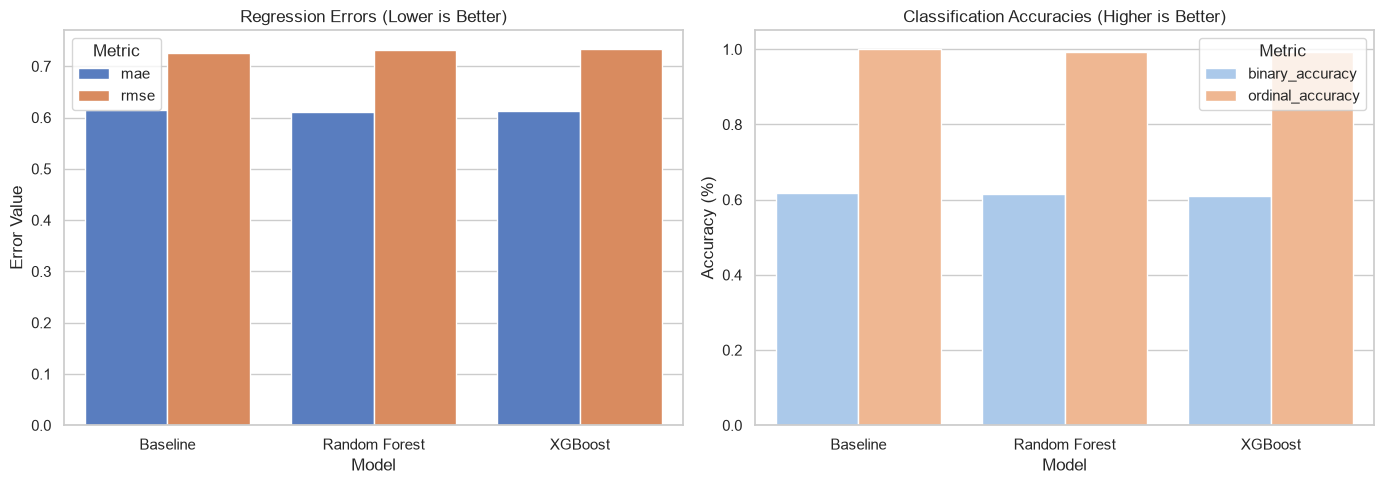

In [4]:
plot_df = metrics_df.reset_index().rename(columns={'index': 'Model'})
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE & RMSE
plot_df_melted = plot_df.melt(id_vars='Model', value_vars=['mae', 'rmse'], var_name='Metric', value_name='Value')
sns.barplot(data=plot_df_melted, x='Model', y='Value', hue='Metric', ax=axes[0], palette='muted')
axes[0].set_title("Regression Errors (Lower is Better)")
axes[0].set_ylabel("Error Value")

# Accuracies
plot_df_acc = plot_df.melt(id_vars='Model', value_vars=['binary_accuracy', 'ordinal_accuracy'], var_name='Metric', value_name='Accuracy')
sns.barplot(data=plot_df_acc, x='Model', y='Accuracy', hue='Metric', ax=axes[1], palette='pastel')
axes[1].set_title("Classification Accuracies (Higher is Better)")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
try:
    plt.savefig('../implementation/model_metrics_comparison.png', dpi=150)
except Exception:
    plt.savefig('implementation/model_metrics_comparison.png', dpi=150)
plt.show()

## 4. Confusion Matrix (XGBoost)

Let's see how our best model (XGBoost) performs across individual sleep quality labels after post-rounding.

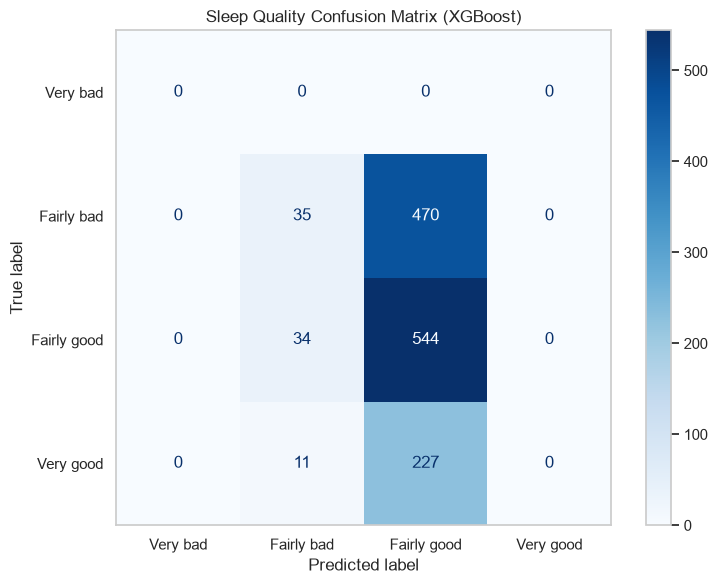

In [5]:
# Round predictions to integers and clip
y_pred_rounded = np.clip(np.round(y_pred_xgb), 0, 3).astype(int)
y_true = y.values.astype(int)

cm = confusion_matrix(y_true, y_pred_rounded, labels=[0, 1, 2, 3])
labels = ['Very bad', 'Fairly bad', 'Fairly good', 'Very good']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Sleep Quality Confusion Matrix (XGBoost)")
plt.grid(False)
plt.tight_layout()
try:
    plt.savefig('../implementation/model_confusion_matrix.png', dpi=150)
except Exception:
    plt.savefig('implementation/model_confusion_matrix.png', dpi=150)
plt.show()

## 5. Predicted vs. Actual Ratings

Let's look at the distribution of continuous predictions against the true ordinal ratings.

C:\Users\HP\AppData\Local\Temp\ipykernel_26228\3722929436.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=y_true, y=y_pred_xgb, jitter=0.25, size=5, alpha=0.5, palette='Set1', legend=False)


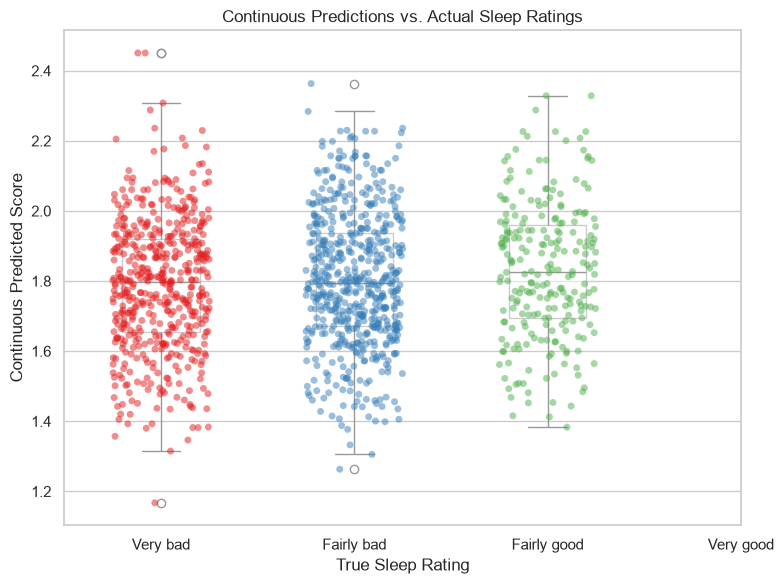

In [6]:
plt.figure(figsize=(8, 6))
sns.stripplot(x=y_true, y=y_pred_xgb, jitter=0.25, size=5, alpha=0.5, palette='Set1', legend=False)
sns.boxplot(x=y_true, y=y_pred_xgb, color='white', width=0.4, boxprops=dict(alpha=0.5))
plt.xticks([0, 1, 2, 3], labels)
plt.title("Continuous Predictions vs. Actual Sleep Ratings")
plt.xlabel("True Sleep Rating")
plt.ylabel("Continuous Predicted Score")
plt.tight_layout()
try:
    plt.savefig('../implementation/model_predictions_vs_actual.png', dpi=150)
except Exception:
    plt.savefig('implementation/model_predictions_vs_actual.png', dpi=150)
plt.show()